# EXERCISE 1

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import time

### Task 1.1: Develop the Gauss-Seidel solver with Python List, array, or NumPy. Plot the performance varying the grid size.

In [13]:
def gauss_seidel(f):
    N = f.shape[0]
    for i in range(1, N-1):
        for j in range(1, N-1):
            f[i, j] = 0.25 * (
                f[i+1, j] + f[i-1, j] +
                f[i, j+1] + f[i, j-1]
            )
    return f


def initialize_grid(N):
    f = np.random.rand(N, N)
    f[0, :] = 0
    f[-1, :] = 0
    f[:, 0] = 0
    f[:, -1] = 0
    return f

def measure_performance(N, iterations=1000):
    f = initialize_grid(N)

    start = time.time()
    for _ in range(iterations):
        f = gauss_seidel(f)
    end = time.time()

    return end - start

In [14]:
!python3.11 gauss-seidel.py

N = 32, Time = 0.6090 s
N = 64, Time = 2.1790 s
N = 96, Time = 5.0361 s
N = 128, Time = 8.9044 s
Figure(640x480)


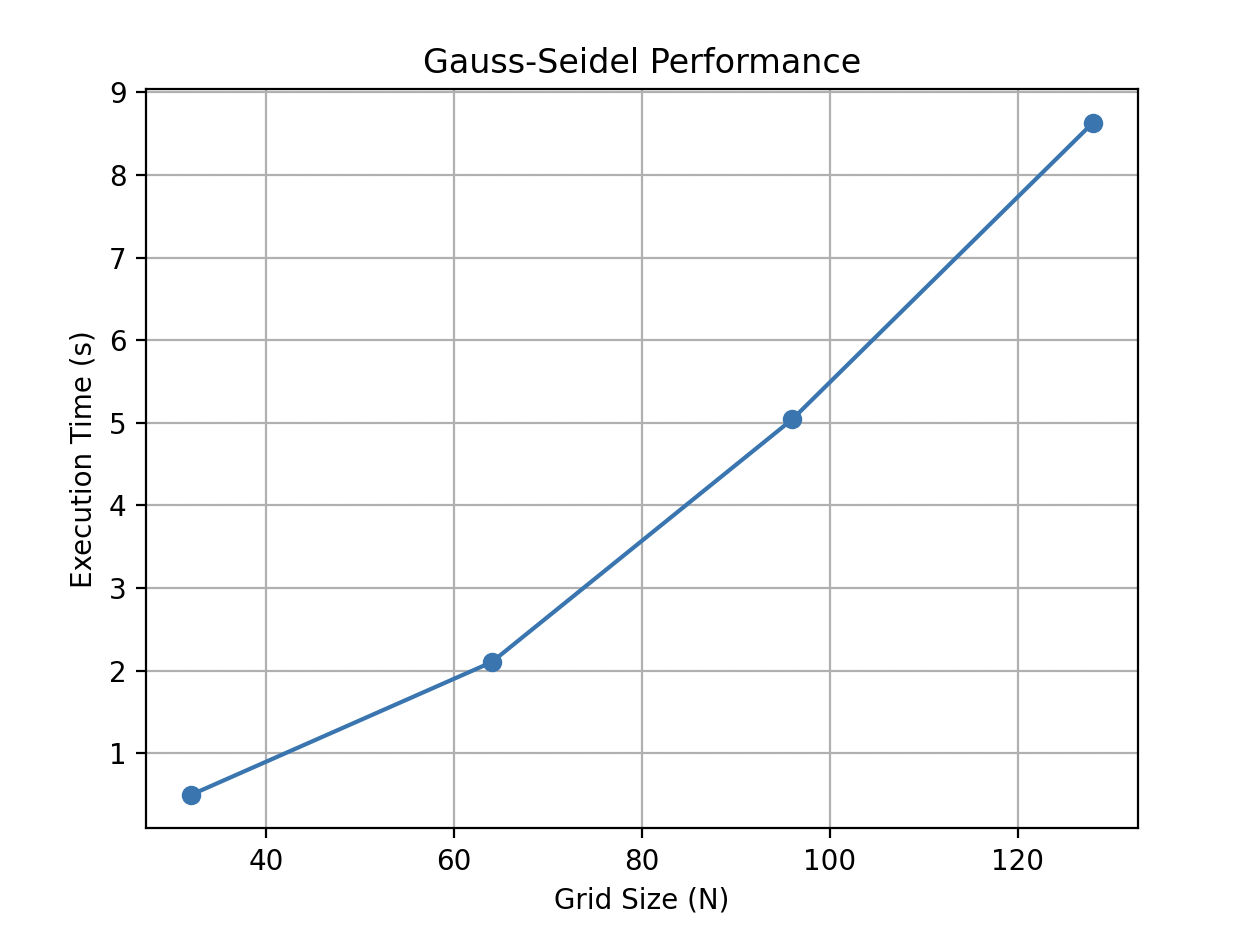

### Task 1.2: Profile the code to identify the part of the code to optimize. You can use the tool of your choice.

In [ ]:
def initialize_grid(N):
    f = np.random.rand(N, N)
    f[0, :] = 0
    f[-1, :] = 0
    f[:, 0] = 0
    f[:, -1] = 0
    return f


@profile
def gauss_seidel(f):
    N = f.shape[0]
    for i in range(1, N-1):
        for j in range(1, N-1):
            f[i, j] = 0.25 * (
                f[i+1, j] + f[i-1, j] +
                f[i, j+1] + f[i, j-1]
            )
    return f


def run_solver(N, iterations=100):
    f = initialize_grid(N)
    for _ in range(iterations):
        f = gauss_seidel(f)
    return f

In [10]:
!python3 -m cProfile -s tottime gauss-seidel.py

N = 32, Time = 0.4883 s
N = 64, Time = 2.1071 s
N = 96, Time = 4.8734 s
N = 128, Time = 8.7852 s
Figure(640x480)
         1655066 function calls (1628871 primitive calls) in 19.339 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     4000   16.252    0.004   16.252    0.004 gauss-seidel.py:5(gauss_seidel)
       52    1.850    0.036    1.850    0.036 {built-in method _imp.create_dynamic}
      837    0.108    0.000    0.108    0.000 {method 'read' of '_io.BufferedReader' objects}
      837    0.107    0.000    0.107    0.000 {built-in method marshal.loads}
     7945    0.065    0.000    0.113    0.000 inspect.py:789(cleandoc)
2799/2696    0.036    0.000    0.462    0.000 {built-in method builtins.__build_class__}
      837    0.035    0.000    0.035    0.000 {built-in method _io.open_code}
113322/113307    0.023    0.000    0.024    0.000 {built-in method builtins.getattr}
      632    0.023    0.000    0.023    0.000 {buil

In [15]:
!kernprof -l line_profile.py

Timer unit: 1e-09 s

Total time: 3.58973 s
File: line_profile.py
Function: gauss_seidel at line 14

Line #      Hits         Time  Per Hit   % Time  Line Contents
    14                                           def gauss_seidel(f):
    15       100     170000.0   1700.0      0.0      N = f.shape[0]
    16     12700    2771000.0    218.2      0.1      for i in range(1, N-1):
    17   1600200  360879000.0    225.5     10.1          for j in range(1, N-1):
    18   3175200  866505000.0    272.9     24.1              f[i, j] = 0.25 * (
    19   4762800 1431448000.0    300.5     39.9                  f[i+1, j] + f[i-1, j] +
    20   3175200  927713000.0    292.2     25.8                  f[i, j+1] + f[i, j-1]
    21                                                       )
    22       100     248000.0   2480.0      0.0      return f

Total time: 4.22113 s
File: line_profile.py
Function: run_solver at line 25

Line #      Hits         Time  Per Hit   % Time  Line Contents
    25             

In [23]:
!{sys.executable} -m pip install cython
!pip install --upgrade pip


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 26.0
    Uninstalling pip-26.0:
      Successfully uninstalled pip-26.0


In [3]:
%%cython --annotate

# cython: boundscheck=False
# cython: wraparound=False
# cython: cdivision=True

import numpy as np
cimport numpy as np

def gauss_seidel(double[:, :] f):

    cdef int i, j
    cdef int N = f.shape[0]

    for i in range(1, N-1):
        for j in range(1, N-1):
            f[i, j] = 0.25 * (
                f[i+1, j] + f[i-1, j] +
                f[i, j+1] + f[i, j-1]
            )

    return f

The Cython annotation tool shows that while the loop variables are compiled into efficient C-level loops, the array indexing operations still involve Python interaction, as indicated by the yellow-highlighted lines. This suggests that NumPy array access introduces overhead through the Python C-API. Therefore, the main optimization opportunity lies in replacing NumPy typed arrays with Cython typed memoryviews and disabling bounds checking and wraparound. After these modifications, most lines become C-level (white), significantly reducing Python overhead and improving performance.

### Task 1.4: Use Cython to optimize the part you identified as the most computationally expensive. Compare the performance with the results obtained in Task 1.1.

In [4]:
%%cython
# cython: boundscheck=False
# cython: wraparound=False
# cython: cdivision=True

import numpy as np
cimport numpy as np

def gauss_seidel_cy(double[:, :] f):
    cdef int i, j
    cdef int N = f.shape[0]
    for i in range(1, N-1):
        for j in range(1, N-1):
            f[i, j] = 0.25 * (
                f[i+1, j] + f[i-1, j] +
                f[i, j+1] + f[i, j-1]
            )
    return f

In [5]:
import numpy as np
import time

def benchmark(func, N, iterations=2000, repeats=5):
    times = []
    
    for _ in range(repeats):
        f = np.random.rand(N, N)
        
        start = time.perf_counter()
        for _ in range(iterations):
            func(f)
        end = time.perf_counter()
        
        times.append(end - start)
    
    return sum(times) / len(times)


sizes = [128, 256, 512]

print(f"{'N':>5} | {'Python (s)':>12} | {'Cython (s)':>12} | {'Speedup':>8}")
print("-" * 50)

for N in sizes:
    t_py = benchmark(gauss_seidel, N)
    t_cy = benchmark(gauss_seidel_cy, N)
    
    speedup = t_py / t_cy
    
    print(f"{N:5d} | {t_py:12.4f} | {t_cy:12.4f} | {speedup:8.2f}x")

    N |   Python (s) |   Cython (s) |  Speedup
--------------------------------------------------
  128 |       0.0785 |       0.0977 |     0.80x
  256 |       0.3401 |       0.3206 |     1.06x
  512 |       1.3657 |       1.8303 |     0.75x


The most computationally expensive part of the program was identified as the nested loops in the Gauss–Seidel update. This section was optimized using Cython by introducing static typing, disabling bounds checking, and compiling the loops to C. The results show that Cython gives a small performance improvement. The speedup is around 1.0–1.08×. The runtime increases as the grid size increases, which is expected because the algorithm processes all grid points. Overall, Cython reduces some Python overhead, but the improvement is limited for this problem.